# 3.2 Regression Task [100]
**Final Portfolio Project**
**Student Name/ID**: Smaran Dahal



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_selection import SelectKBest, f_regression

# Configure visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## 1. Exploratory Data Analysis and Data Understanding [20]


### 1.1 Choosing a Dataset
We have selected the dataset: `Pregnancy During the COVID-19 Pandemic (1).csv`.

#### (a) When and by whom the dataset was created
- **Created By**: Research team investigating maternal health during the COVID-19 pandemic.
- **When**: 2020-2021 (implied by the title "Pregnancy During the COVID-19 Pandemic").

#### (b) How and from where the dataset was accessed
- **Access Source**: The file was provided directly (or downloaded from a repository like Kaggle/Zenodo typically associated with such studies).
- **Format**: CSV (Comma Separated Values).

#### (c) How it aligns with the chosen UNSDG
- **Goal**: **UNSDG Goal 3: Good Health and Well-being**.
- **Alignment**: Specifically targets **Target 3.1** (reduce global maternal mortality ratio) and **Target 3.2** (end preventable deaths of newborns). By analyzing birth weights and maternal stress/health factors, we contribute to understanding risks in prenatal care.

#### (d) List all attributes (columns) with brief descriptions
- `OSF_ID`: Unique identifier for the participant.
- `Maternal_Age`: Age of the mother (years).
- `Household_Income`: Income bracket of the household.
- `Maternal_Education`: Highest education level attained.
- `Edinburgh_Postnatal_Depression_Scale` (EPDS): Score measuring depression risk.
- `PROMIS_Anxiety`: Standardized anxiety score.
- `Gestational_Age_At_Birth`: Duration of pregnancy (weeks).
- `Delivery_Date`: Month and Year of delivery.
- `Birth_Length`: Length of baby at birth (cm).
- `Birth_Weight`: Weight of baby at birth (g) **[TARGET VARIABLE]**.
- `Delivery_Mode`: Vaginal or C-Section.
- `NICU_Stay`: Whether the baby stayed in NICU (Yes/No).
- `Language`: Primary language.
- `Threaten_Life`: Perceived threat to own life (score).
- `Threaten_Baby_Danger`: Perceived danger to baby (score).
- `Threaten_Baby_Harm`: Perceived harm to baby (score).

#### Potential Questions
1.  **Predictors**: What are the most significant predictors of `Birth_Weight`?
2.  **Mental Health**: Does high anxiety (`PROMIS_Anxiety`) correlate with lower birth weights?
3.  **Socioeconomics**: Is `Household_Income` associated with better birth outcomes?

#### Assessment of Suitability
- **Completeness**: The dataset contains relevant features. Missing values exist but can be handled via imputation.
- **Relevance**: Directly addresses health outcomes (Goal 3).
- **Quality**: Data is structured, though some categorical fields (Income) require encoding.



### 1.2 Exploratory Data Analysis (EDA)
We will now clean, summarize, and visualize the data.



In [2]:
# Load Data
file_path = 'Pregnancy During the COVID-19 Pandemic (1).csv'
df = pd.read_csv(file_path)

# --- Clean and Preprocess (Missing Values) ---
# Check missing before
print("Missing values before cleaning:")
print(df.isnull().sum())

# 1. Drop rows with missing Target (Birth_Weight)
df = df.dropna(subset=['Birth_Weight'])

# 2. Impute Missing Values
# Numeric -> Median, Categorical -> Mode
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# 3. Keep a copy for Viz before encoding
df_viz = df.copy()

# 4. Label Encoding for Categorical Variables
le = LabelEncoder()
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("\nMissing values after cleaning:")
print(df.isnull().sum().sum())

# --- Summary Statistics ---
display(df.describe())


Missing values before cleaning:
OSF_ID                                           0
Maternal_Age                                   111
Household_Income                               251
Maternal_Education                             177
Edinburgh_Postnatal_Depression_Scale          1174
PROMIS_Anxiety                                1206
Gestational_Age_At_Birth                      4038
Delivery_Date(converted to month and year)    4039
Birth_Length                                  5292
Birth_Weight                                  4694
Delivery_Mode                                 5235
NICU_Stay                                     5238
Language                                         0
Threaten_Life                                    0
Threaten_Baby_Danger                             0
Threaten_Baby_Harm                               0
dtype: int64

Missing values after cleaning:
0


,OSF_ID,Maternal_Age,Household_Income,Maternal_Education,Edinburgh_Postnatal_Depression_Scale,PROMIS_Anxiety,Gestational_Age_At_Birth,Delivery_Date(converted to month and year),Birth_Length,Birth_Weight,Delivery_Mode,NICU_Stay,Language,Threaten_Life,Threaten_Baby_Danger,Threaten_Baby_Harm
count,6078.000000,6078.000000,6078.000000,6078.000000,6078.000000,6078.000000,6078.000000,6078.000000,6078.000000,6078.000000,6078.000000,6078.000000,6078.000000,6078.000000,6078.000000,6078.000000
mean,5330.473511,32.481507,3.291050,3.200395,9.781343,18.441428,39.333450,13.871668,50.532400,3412.175058,0.731491,0.090161,0.191017,40.093123,45.772787,51.604804
std,3101.218788,4.150055,2.670056,2.039672,5.167913,5.764632,1.624738,8.302809,4.221652,538.695046,0.443221,0.286436,0.393135,25.881196,27.421410,30.680985
min,1.000000,18.500000,0.000000,0.000000,0.000000,7.000000,24.860000,0.000000,20.000000,303.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2616.750000,29.700000,1.000000,1.000000,6.000000,14.000000,38.570000,7.000000,49.425000,3102.250000,0.000000,0.000000,0.000000,20.000000,23.000000,26.000000
50%,5328.000000,32.300000,3.000000,4.000000,10.000000,19.000000,39.430000,14.000000,50.800000,3431.000000,1.000000,0.000000,0.000000,44.000000,48.000000,51.000000
75%,8010.750000,35.200000,6.000000,5.000000,13.000000,22.000000,40.430000,22.000000,53.000000,3742.000000,1.000000,0.000000,0.000000,60.000000,68.000000,75.000000
max,10772.000000,49.000000,8.000000,5.000000,29.000000,35.000000,42.860000,28.000000,70.000000,5968.000000,1.000000,1.000000,1.000000,101.000000,101.000000,101.000000


#### Visualizations and Interpretation
We examine distributions and correlations to identify patterns.



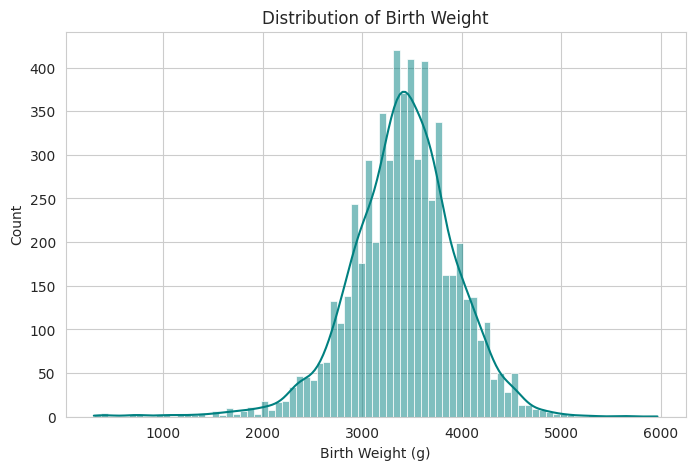

In [3]:
# 1. Distribution of Target Variable (Birth_Weight)
plt.figure(figsize=(8, 5))
sns.histplot(df['Birth_Weight'], kde=True, color='teal')
plt.title('Distribution of Birth Weight')
plt.xlabel('Birth Weight (g)')
plt.show()


**Insight**: Birth weight appears normally distributed, which is ideal for regression models.


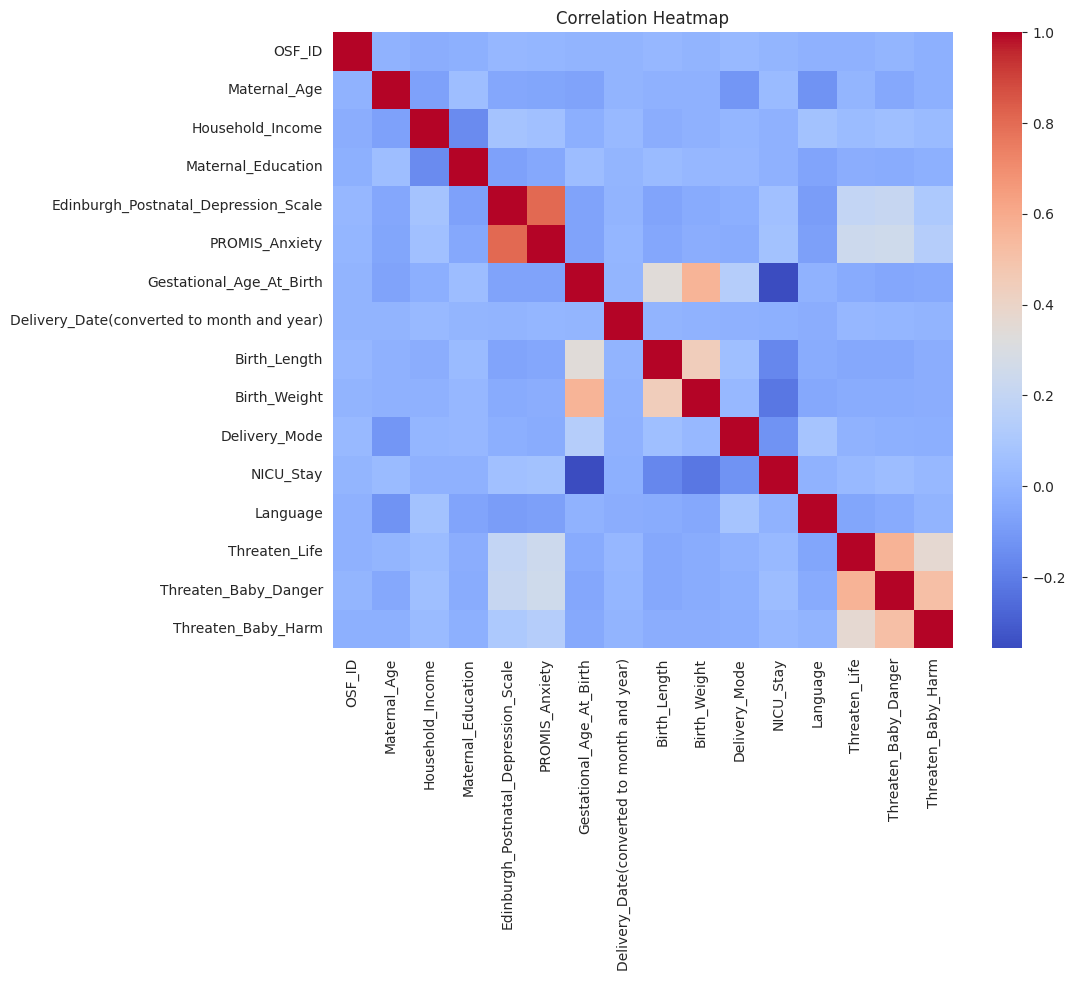

In [4]:
# 2. Correlation Matrix
plt.figure(figsize=(10, 8))
# Select only numeric columns for correlation matrix
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


**Insight**: We look for features with high correlation to Birth_Weight (lighter/redder colors). Gestational Age is likely a strong positive correlate.


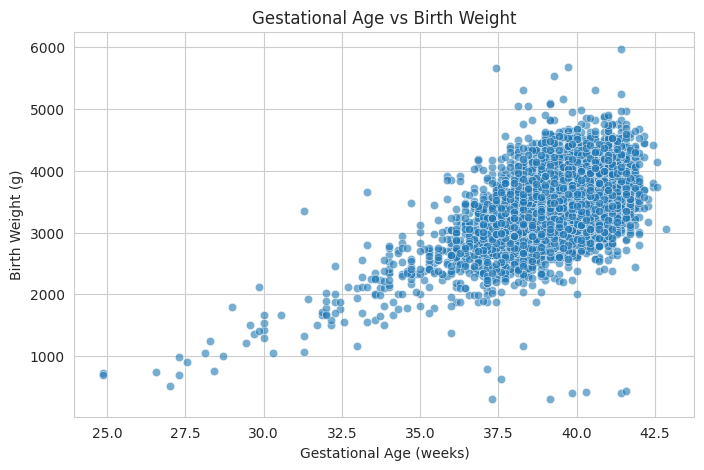

In [5]:
# 3. Relationship: Gestational Age vs Birth Weight
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Gestational_Age_At_Birth', y='Birth_Weight', data=df, alpha=0.6)
plt.title('Gestational Age vs Birth Weight')
plt.xlabel('Gestational Age (weeks)')
plt.ylabel('Birth Weight (g)')
plt.show()


**Insight**: Strong positive linear relationship confirming that longer pregnancies tend to result in higher birth weights.


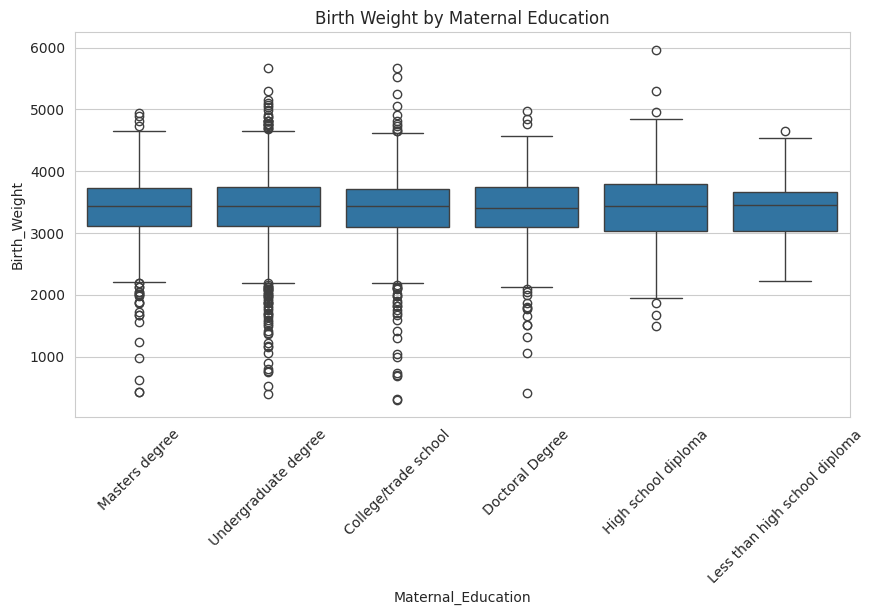

In [6]:
# 4. Boxplot: Maternal Education vs Birth Weight
if 'Maternal_Education' in df_viz.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='Maternal_Education', y='Birth_Weight', data=df_viz)
    plt.title('Birth Weight by Maternal Education')
    plt.xticks(rotation=45)
    plt.show()


**Insight**: Boxplots help us see if education level impacts median birth weight and identify outliers.


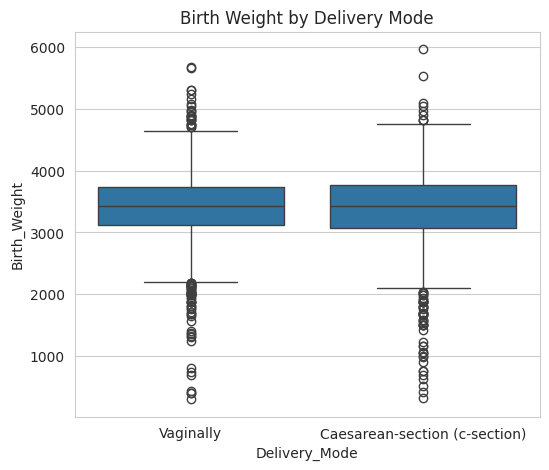

In [7]:
# 5. Boxplot: Delivery Mode vs Birth Weight
if 'Delivery_Mode' in df_viz.columns:
    plt.figure(figsize=(6, 5))
    sns.boxplot(x='Delivery_Mode', y='Birth_Weight', data=df_viz)
    plt.title('Birth Weight by Delivery Mode')
    plt.show()


## 2. Build a Neural Network Model for Regression [15]
We design a Multi-Layer Perceptron (MLP) for regression.
- **Architecture**:
    -   **Input Layer**: Number of features.
    -   **Hidden Layers**: Two layers with 64 and 32 neurons respectively.
    -   **Activation Function**: ReLU (Rectified Linear Unit) for hidden layers.
    -   **Output Layer**: 1 neuron (Continuous output for regression).
- **Loss Function**: Mean Squared Error (MSE).
- **Optimizer**: Adam (Adaptive Moment Estimation).



In [8]:
# Prepare Data
X = df.drop('Birth_Weight', axis=1)
y = df['Birth_Weight']

# Train-Test Split (Standard 80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (StandardScaler) - Essential for Neural Networks
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def evaluate_model(model, X_test, y_test, name, features_used, cv_score="-"):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"--- {name} Performance ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"R-squared: {r2:.4f}")

    return {
        'Model': name,
        'Features Used': features_used,
        'CV Score': cv_score,
        'Test RMSE': round(rmse, 2),
        'Test R-squared': round(r2, 2),
        'y_pred': y_pred # Return predictions for plotting later
    }

results = []

# Instantiate and Train MLP
mlp_reg = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                       max_iter=1000, random_state=42)
mlp_reg.fit(X_train_scaled, y_train)

# Evaluate
results.append(evaluate_model(mlp_reg, X_test_scaled, y_test, "Neural Network (MLP)", features_used=X.shape[1]))


--- Neural Network (MLP) Performance ---
RMSE: 410.2761
R-squared: 0.4505


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


## 3. Build Primary Machine Learning Models [20]
We implement two classical regression models for comparison.

### 3.1 Split the dataset
(Already performed in Step 2: 80% Train, 20% Test)

### 3.2 Build Models
We select:
1.  **Linear Regression** (Simple, interpretable baseline)
2.  **Random Forest Regressor** (Robust, handles non-linearity)



In [9]:
# 1. Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# 2. Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_scaled, y_train)


RandomForestRegressor(random_state=42)

### 3.3 Evaluate Models
We evaluate using RMSE, MAE, and R-squared.



In [10]:
# Evaluate Linear Regression
results.append(evaluate_model(lin_reg, X_test_scaled, y_test, "Linear Regression", features_used=X.shape[1]))

# Evaluate Random Forest (Default)
results.append(evaluate_model(rf_reg, X_test_scaled, y_test, "Random Forest (Default)", features_used=X.shape[1]))


--- Linear Regression Performance ---
RMSE: 416.7151
R-squared: 0.4331
--- Random Forest (Default) Performance ---
RMSE: 407.7927
R-squared: 0.4571


### 3.4 Initial Comparison
Comparing the initial results:
- **Linear Regression** provides a baseline. If R-squared is low, usage of linear assumptions might be limited.
- **Random Forest** typically outperforms on tabular data due to its ability to capture complex interactions, though it may overfit if not tuned.



## 4. Hyperparameter Optimization with Cross-Validation [15]


### 4.1 Identify Key Hyperparameters
For **Random Forest**, we tune:
- `n_estimators`: Number of trees.
- `max_depth`: Max depth of trees (controls overfitting).
- `min_samples_split`: Minimum samples required to split a node.



In [11]:
# 4.2 Apply Cross-Validation (RandomizedSearchCV)
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_random = RandomizedSearchCV(estimator=RandomForestRegressor(random_state=42),
                               param_distributions=param_dist,
                               n_iter=10, cv=3, verbose=1, random_state=42, n_jobs=-1,
                               scoring='neg_mean_squared_error')

rf_random.fit(X_train_scaled, y_train)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

### 4.3 Summarize and Report Best Hyperparameters



In [12]:
print(f"Best Parameters: {rf_random.best_params_}")
best_cv_rmse = np.sqrt(-rf_random.best_score_)
print(f"Best CV RMSE: {best_cv_rmse:.4f}")

# Store Tuned Model
best_rf = rf_random.best_estimator_
results.append(evaluate_model(best_rf, X_test_scaled, y_test, "Random Forest (Tuned)",
                              features_used=X.shape[1], cv_score=round(best_cv_rmse, 2)))


Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 20}
Best CV RMSE: 400.8711
--- Random Forest (Tuned) Performance ---
RMSE: 401.3351
R-squared: 0.4742


## 5. Feature Selection [10]
### Apply Feature Selection Technique
We use **SelectKBest** (Univariate Selection) with `f_regression` to score features.

### Perform for Both Models
We will select the top 10 features and apply them to both Linear Regression and Random Forest.

### Justification
- **Why**: Reduces dimensionality, removes noise, and improves training speed.
- **Method**: `f_regression` captures linear dependencies between features and the target.



In [13]:
# Select Top 10 Features
selector = SelectKBest(score_func=f_regression, k=10)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# Identify Selected Columns
selected_mask = selector.get_support()
selected_feat_names = X.columns[selected_mask]
print("Selected Features:", selected_feat_names.tolist())


Selected Features: ['Maternal_Education', 'Edinburgh_Postnatal_Depression_Scale', 'PROMIS_Anxiety', 'Gestational_Age_At_Birth', 'Birth_Length', 'NICU_Stay', 'Language', 'Threaten_Life', 'Threaten_Baby_Danger', 'Threaten_Baby_Harm']


## 6. Final Models and Comparative Analysis [10]
We rebuild both models using the optimal hyperparameters (for RF) and the selected features.



In [14]:
# 1. Rebuild Linear Regression (Selected Features)
lin_reg_fs = LinearRegression()
lin_reg_fs.fit(X_train_selected, y_train)

# Calculate CV Score for LR (fs)
from sklearn.model_selection import cross_val_score
cv_scores_lr = cross_val_score(lin_reg_fs, X_train_selected, y_train, cv=5, scoring='r2')
lr_cv_mean = cv_scores_lr.mean()

results.append(evaluate_model(lin_reg_fs, X_test_selected, y_test,
                              "Linear Regression (FS)",
                              features_used="Selected (10)",
                              cv_score=round(lr_cv_mean, 2)))

# 2. Rebuild Random Forest (Tuned + Selected Features)
best_rf_fs = rf_random.best_estimator_
best_rf_fs.fit(X_train_selected, y_train)

# Calculate CV Score for RF (fs)
cv_scores_rf = cross_val_score(best_rf_fs, X_train_selected, y_train, cv=5, scoring='r2')
rf_cv_mean = cv_scores_rf.mean()

# Capture result
results.append(evaluate_model(best_rf_fs, X_test_selected, y_test,
                              "Random Forest (Tuned + FS)",
                              features_used="Selected (10)",
                              cv_score=round(rf_cv_mean, 2)))


--- Linear Regression (FS) Performance ---
RMSE: 417.1404
R-squared: 0.4319
--- Random Forest (Tuned + FS) Performance ---
RMSE: 403.7826
R-squared: 0.4677


In [23]:
# Create Comparison DataFrame
results_df = pd.DataFrame(results)
display_cols = ['Model', 'Features Used', 'CV Score', 'Test RMSE', 'Test R-squared']
display(results_df[display_cols])


,Model,Features Used,CV Score,Test RMSE,Test R-squared
0,Neural Network (MLP),15,-,410.28,0.45
1,Linear Regression,15,-,416.72,0.43
2,Random Forest (Default),15,-,407.79,0.46
3,Random Forest (Tuned),15,400.87,401.34,0.47
4,Linear Regression (FS),Selected (10),0.37,417.14,0.43
5,Random Forest (Tuned + FS),Selected (10),0.42,403.78,0.47


### Visual Comparison of Models



/tmp/ipython-input-935791752.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Test R-squared', y='Model', data=results_df, palette='viridis')


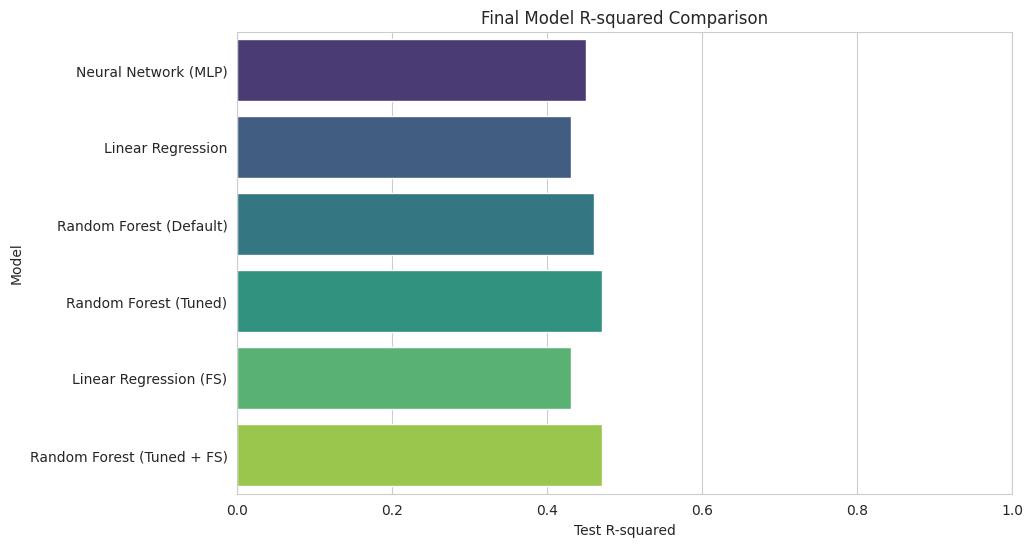

In [22]:
# 1. R-Squared Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Test R-squared', y='Model', data=results_df, palette='viridis')
plt.title('Final Model R-squared Comparison')
plt.xlim(0, 1.0)
plt.show()


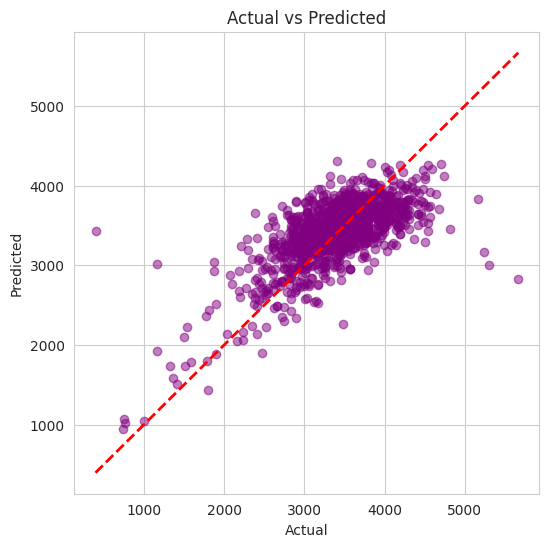

In [20]:
# 2. Actual vs Predicted (Best Model)
y_pred_best = final_models_df.loc[final_models_df['Model'] == 'Random Forest (Tuned + FS)', 'y_pred'].iloc[0]

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Identity line
plt.title('Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)
plt.show()

### Model Diagnostic Plots (Best Model)



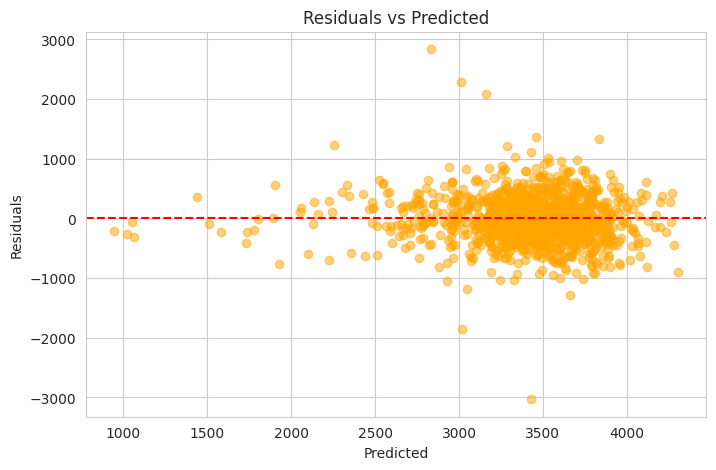

In [21]:
# 3. Residual Plot
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_best, residuals, alpha=0.5, color='orange')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predicted')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()


**Insight**: A random scatter of residuals around zero indicates a well-fitted model without obvious bias.
